C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1840\1271728270.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


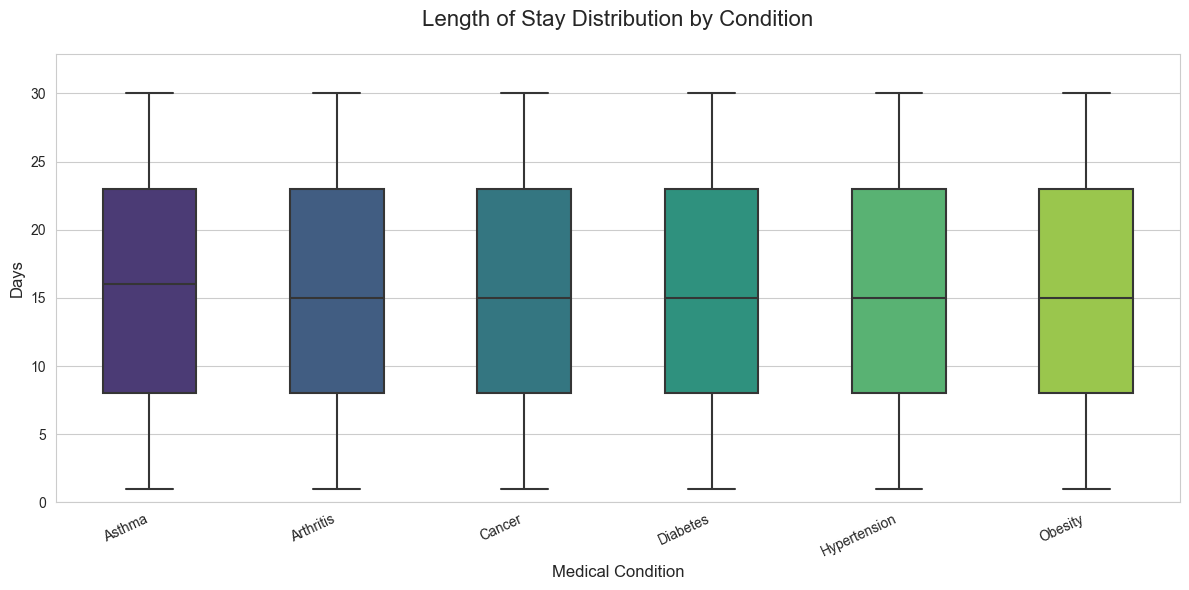

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Data
# Assuming the file is named 'healthcare_dataset.csv' inside the 'data' folder
file_path = 'data/healthcare_dataset.csv'

try:
    df = pd.read_csv(file_path)
    
    # 2. Preprocessing: Calculate Length of Stay
    # Convert date columns to datetime objects
    df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
    df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

    # Calculate difference in days (replicating the JS logic)
    df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

    # 3. Sort Logic: Median Descending
    # In your JS: .sort((a, b) => b.median - a.median)
    # In Python: We calculate medians first to define the order
    median_order = df.groupby('Medical Condition')['Length of Stay'].median().sort_values(ascending=False).index

    # 4. Setup the Plot
    plt.figure(figsize=(12, 6))
    
    # Set style to match your dashboard (White background with grid lines)
    sns.set_style("whitegrid") 

    # 5. Draw the Box Plot
    # This automatically calculates Q1, Q3, Median, Whiskers, and Outliers
    ax = sns.boxplot(
        data=df,
        x='Medical Condition',
        y='Length of Stay',
        order=median_order,     # Apply the median sort order
        palette='viridis',      # Accessible color palette
        width=0.5,              # Adjust box width
        showfliers=True,        # Show outliers (dots)
        linewidth=1.5
    )

    # 6. Styling to Match Dashboard
    plt.title('Length of Stay Distribution by Condition', fontsize=16, pad=20)
    plt.xlabel('Medical Condition', fontsize=12)
    plt.ylabel('Days', fontsize=12)

    # Rotate x-axis labels to match the JS "rotate(-25)"
    plt.xticks(rotation=25, ha='right')

    # "Zoomed In" Y-Axis Logic
    # Matplotlib usually autoscales tightly, but we can enforce the JS logic:
    # [min - padding, max + padding]
    y_min = df['Length of Stay'].min()
    y_max = df['Length of Stay'].max()
    padding = (y_max - y_min) * 0.10
    
    # Ensure we don't go below 0
    plt.ylim(max(0, y_min - padding), y_max + padding)

    # Render
    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find file at {file_path}. Please check the filename.")
except Exception as e:
    print(f"An error occurred: {e}")